**Import Libraries and Load Dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

In [ ]:
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')

In [ ]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [ ]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
matches.shape

(1095, 20)

In [ ]:
deliveries.shape

(260920, 17)

In [ ]:
matches['team1'].value_counts()

,count
team1,
Royal Challengers Bangalore,135
Chennai Super Kings,128
Mumbai Indians,123
Kolkata Knight Riders,121
Rajasthan Royals,101
Kings XI Punjab,92
Sunrisers Hyderabad,86
Delhi Daredevils,85
Delhi Capitals,41


In [ ]:
matches['team2'].value_counts()

,count
team2,
Mumbai Indians,138
Kolkata Knight Riders,130
Rajasthan Royals,120
Chennai Super Kings,110
Royal Challengers Bangalore,105
Kings XI Punjab,98
Sunrisers Hyderabad,96
Delhi Daredevils,76
Delhi Capitals,50


In [ ]:
deliveries['batting_team'].value_counts()

,count
batting_team,
Mumbai Indians,31437
Kolkata Knight Riders,29514
Chennai Super Kings,28651
Royal Challengers Bangalore,28205
Rajasthan Royals,26242
Kings XI Punjab,22646
Sunrisers Hyderabad,21843
Delhi Daredevils,18786
Delhi Capitals,10946


**Data Cleaning**

In [ ]:
matches['team1'].replace({'Rising Pune Supergiants' : 'Rising Pune Supergiant'}, inplace=True)
matches['team2'].replace({'Rising Pune Supergiants' : 'Rising Pune Supergiant'}, inplace=True)
matches['toss_winner'].replace({'Rising Pune Supergiants' : 'Rising Pune Supergiant'}, inplace=True)
matches['winner'].replace({'Rising Pune Supergiants' : 'Rising Pune Supergiant'}, inplace=True)

matches['team1'].replace({'Royal Challengers Bengaluru' : 'Royal Challengers Bangalore'}, inplace=True)
matches['team2'].replace({'Royal Challengers Bengaluru' : 'Royal Challengers Bangalore'}, inplace=True)
matches['toss_winner'].replace({'Royal Challengers Bengaluru' : 'Royal Challengers Bangalore'}, inplace=True)
matches['winner'].replace({'Royal Challengers Bengaluru' : 'Royal Challengers Bangalore'}, inplace=True)

/tmp/ipykernel_3323/2290439371.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['team1'].replace({'Rising Pune Supergiants' : 'Rising Pune Supergiant'}, inplace=True)
/tmp/ipykernel_3323/2290439371.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

In [ ]:
matches['team2'].value_counts()

,count
team2,
Mumbai Indians,138
Kolkata Knight Riders,130
Rajasthan Royals,120
Royal Challengers Bangalore,111
Chennai Super Kings,110
Kings XI Punjab,98
Sunrisers Hyderabad,96
Delhi Daredevils,76
Delhi Capitals,50


In [ ]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [ ]:
deliveries['batting_team'].replace({'Rising Pune Supergiants' : 'Rising Pune Supergiant'}, inplace=True)
deliveries['bowling_team'].replace({'Rising Pune Supergiants' : 'Rising Pune Supergiant'}, inplace=True)

/tmp/ipykernel_3323/3733926949.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries['batting_team'].replace({'Rising Pune Supergiants' : 'Rising Pune Supergiant'}, inplace=True)
/tmp/ipykernel_3323/3733926949.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [ ]:
deliveries['batting_team'].value_counts()

,count
batting_team,
Mumbai Indians,31437
Kolkata Knight Riders,29514
Chennai Super Kings,28651
Royal Challengers Bangalore,28205
Rajasthan Royals,26242
Kings XI Punjab,22646
Sunrisers Hyderabad,21843
Delhi Daredevils,18786
Delhi Capitals,10946


In [ ]:
matches['city'].fillna('Unknown')

,city
0,Bangalore
1,Chandigarh
2,Delhi
3,Mumbai
4,Kolkata
...,...
1090,Hyderabad
1091,Ahmedabad
1092,Ahmedabad
1093,Chennai


In [ ]:
matches['city'].isna().sum()

np.int64(51)

In [ ]:
matches['method'].value_counts()

,count
method,
D/L,21


In [ ]:
matches['city'].fillna('Unknown', inplace=True)
matches['method'].fillna('Non D/L', inplace=True)

/tmp/ipykernel_3323/1193831869.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['city'].fillna('Unknown', inplace=True)
/tmp/ipykernel_3323/1193831869.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

**Success Rate of IPL Teams**

In [ ]:
def random_colors(no_of_colors):
  return ['#'+''.join( [np.random.choice( list('0123456789ABCDEF')) for _ in range(6) ] ) for _ in range(no_of_colors) ]

In [ ]:
random_colors(6)

['#C0385E', '#E81113', '#64E73C', '#1C62BD', '#D6B038', '#B63231']

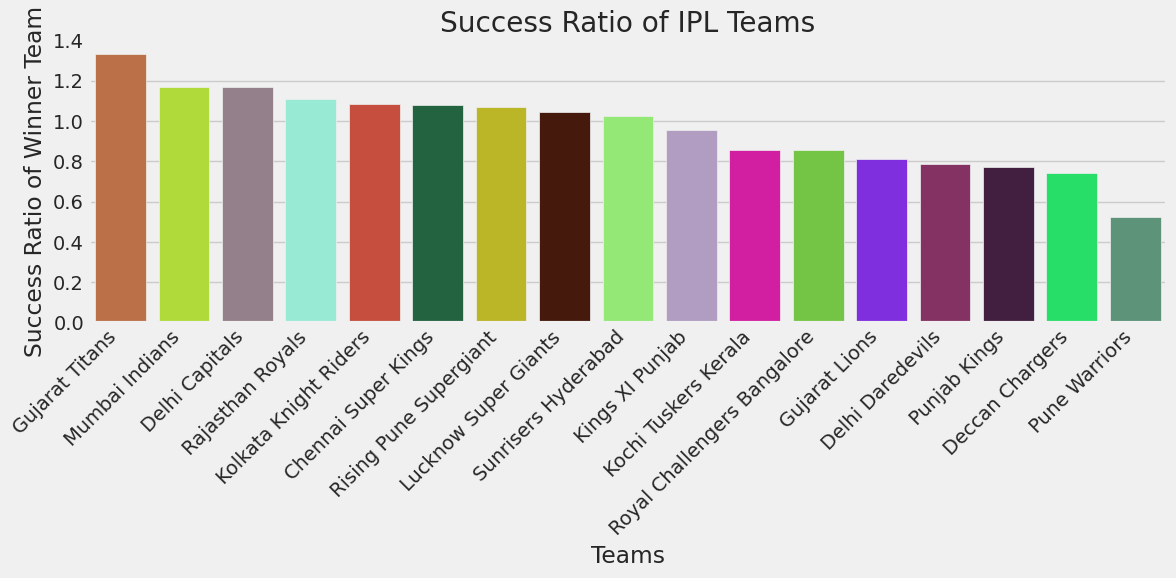

In [ ]:
success_ratio = matches.groupby('winner').count()['id'] / matches.groupby('team1').count()['id']
success_ratio_desc = success_ratio.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=success_ratio_desc.index, y=success_ratio_desc.values, palette=random_colors(len(success_ratio_desc)),
            hue=success_ratio_desc.index, legend=False)
plt.title('Success Ratio of IPL Teams')
plt.xlabel('Teams')
plt.ylabel('Success Ratio of Winner Team')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Most Titles Wins By IPL Teams**

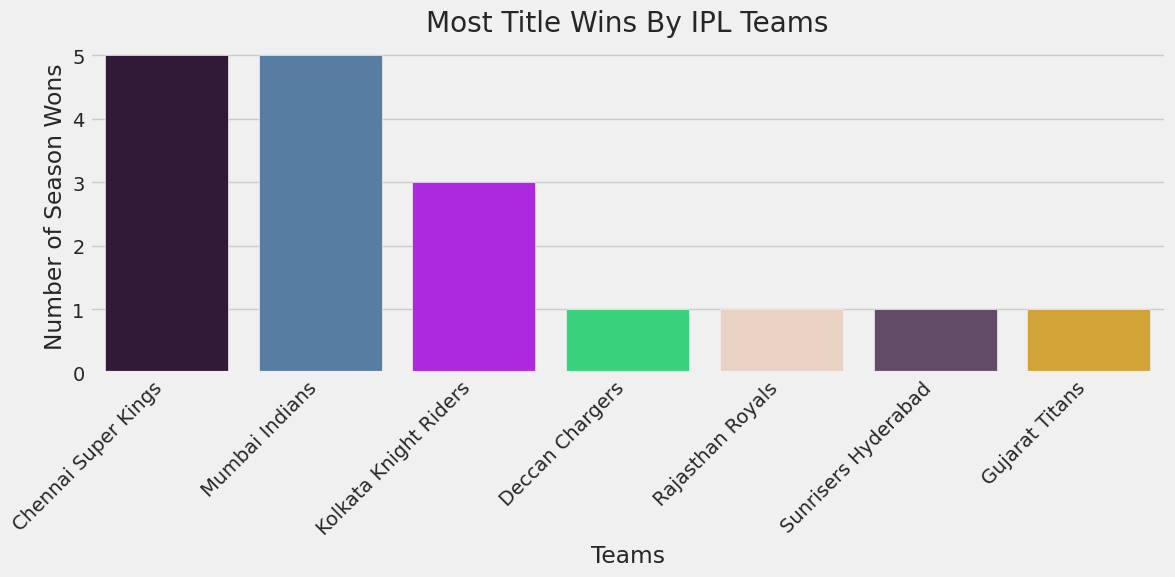

In [ ]:
winner_counts = matches.groupby('season')[['season', 'winner']].tail(1)['winner'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=winner_counts.index, y=winner_counts.values, palette=random_colors(len(winner_counts)),
            hue=winner_counts.index, legend=False)
plt.title('Most Title Wins By IPL Teams')
plt.xlabel('Teams')
plt.ylabel('Number of Season Wons')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Top 10 Players with Most Runs**

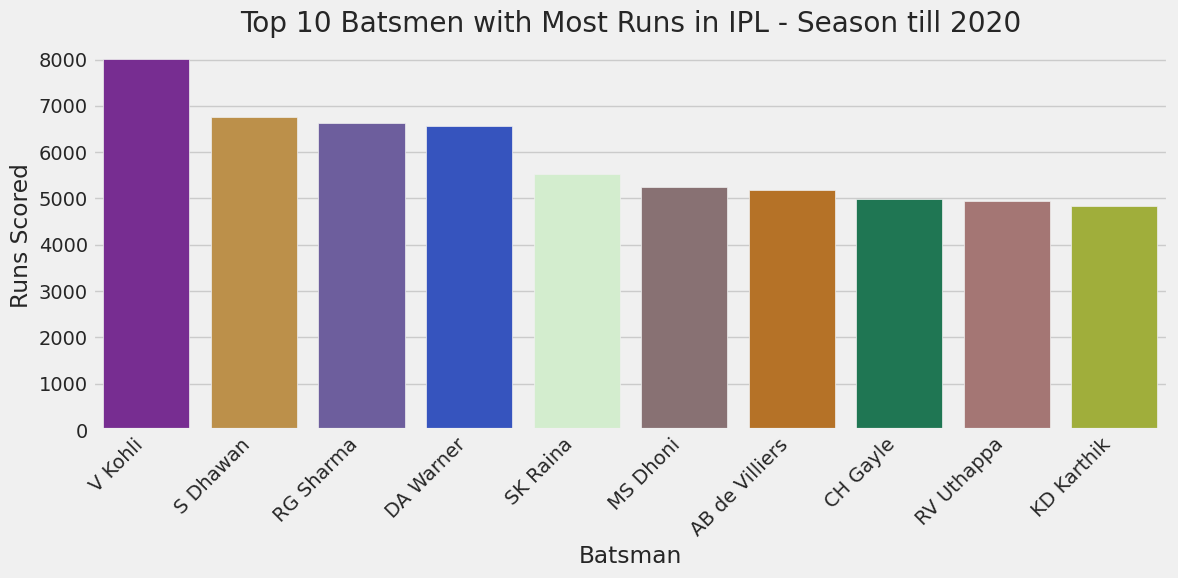

In [ ]:
batting_tot = deliveries.groupby('batter')['batsman_runs'].sum().reset_index(name='Runs')
top_batsmen = batting_tot.sort_values(by='Runs', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x='batter', y='Runs', data = top_batsmen,
            palette=random_colors(10), hue=top_batsmen.index, legend=False)
plt.title('Top 10 Batsmen with Most Runs in IPL - Season till 2020')
plt.xlabel('Batsman')
plt.ylabel('Runs Scored')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Top 10 Best Performances in IPL Matches**

In [ ]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN


In [ ]:
batting_ings = deliveries.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index(name='Innings Runs')
top_batsmen_scores = batting_ings.sort_values(by='Innings Runs', ascending=False).head(10)


In [ ]:
batsman_ball_faced = deliveries.groupby(['match_id', 'batter'])['batsman_runs'].count().reset_index(name='Balls Faced')

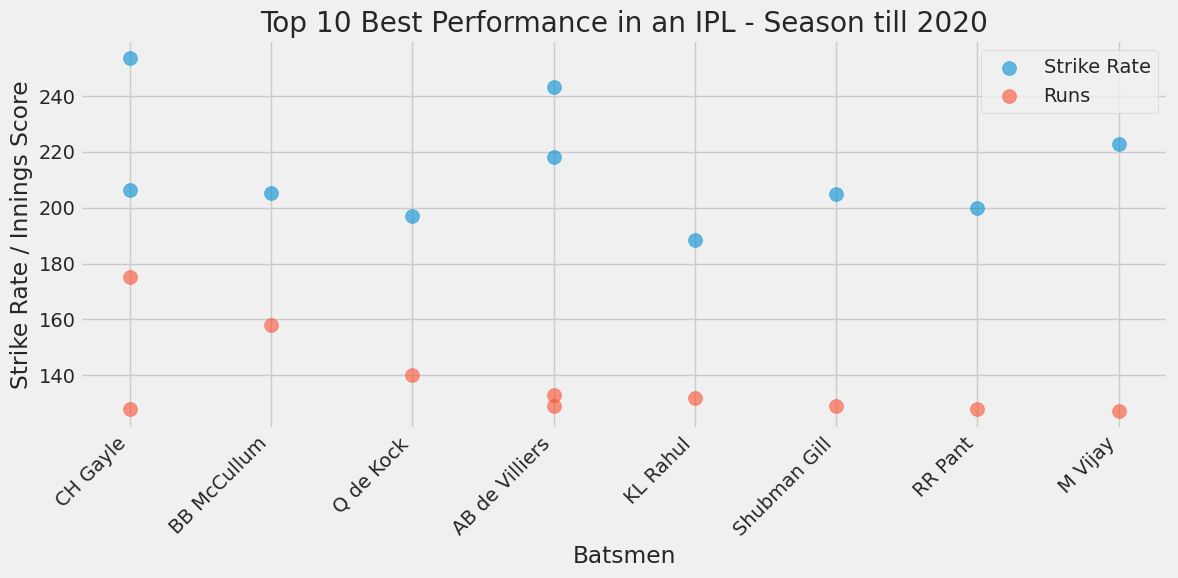

In [ ]:
batsmen_performance = pd.merge(top_batsmen_scores, batsman_ball_faced, on=['match_id', 'batter'], how='inner')
batsmen_performance['Strike Rate for Match'] = np.round(batsmen_performance['Innings Runs'] * 100 / batsmen_performance['Balls Faced'],2)
batsmen_performance

plt.figure(figsize=(12,6))
plt.scatter(batsmen_performance['batter'], batsmen_performance['Strike Rate for Match'],
                label='Strike Rate', s=100,alpha=0.6)
plt.scatter(batsmen_performance['batter'], batsmen_performance['Innings Runs'],
                label='Runs', s=100,alpha=0.6)
plt.title('Top 10 Best Performance in an IPL - Season till 2020')
plt.xlabel('Batsmen')
plt.ylabel('Strike Rate / Innings Score')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Top 10 Best Bowlers in IPL Season Till 2020**

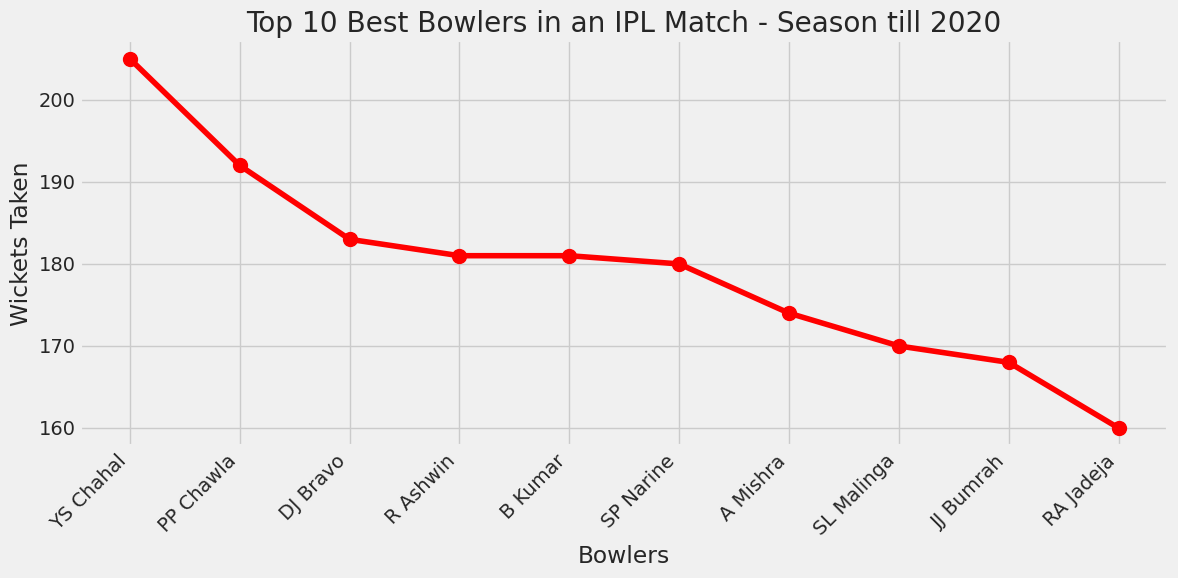

In [ ]:
bowling_wickets = deliveries[deliveries['dismissal_kind'] != 'run out']
top_bowlers = bowling_wickets.groupby('bowler')['dismissal_kind'].count().reset_index(
    name='Wickets').sort_values(by='Wickets', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.plot(top_bowlers['bowler'], top_bowlers['Wickets'], marker='o', ms=10, linestyle='-', color='red')

plt.title('Top 10 Best Bowlers in an IPL Match - Season till 2020')
plt.xlabel('Bowlers')
plt.ylabel('Wickets Taken')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Top 10 Bowling Performances in IPL Season Till 2020**

In [ ]:
match_bowling_top = bowling_wickets.groupby(['match_id','bowler'])['dismissal_kind'].count().reset_index(
    name='Wickets').sort_values(by='Wickets',ascending=False)[:10]

In [ ]:
match_bowler_runs = deliveries.groupby(['match_id','bowler'])['total_runs'].sum().reset_index(name='Runs Conceded')

In [ ]:
match_bowler_performance = pd.merge(match_bowler_runs,match_bowling_top,how='inner', on =['match_id','bowler'])

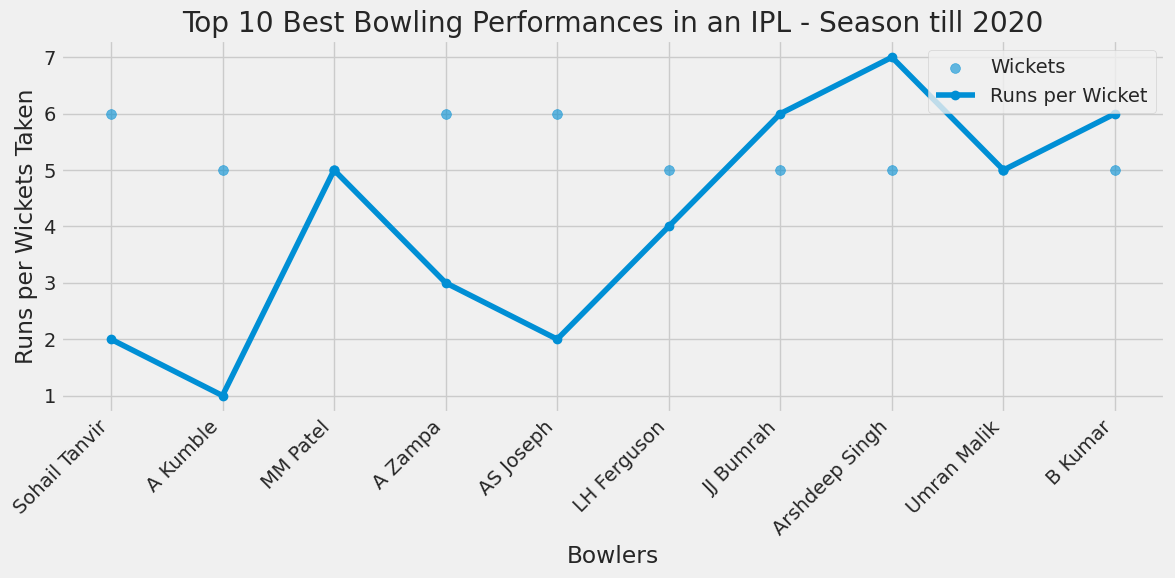

In [ ]:
match_bowler_performance['Runs per Wicket'] = np.round(match_bowler_performance['Runs Conceded']/match_bowler_performance['Wickets'],0)

plt.figure(figsize=(12,6))
plt.scatter(match_bowler_performance['bowler'], match_bowler_performance['Wickets'], label="Wickets", s=50, alpha=0.6)
plt.plot(match_bowler_performance['bowler'], match_bowler_performance['Runs per Wicket'], marker='o', label='Runs per Wicket')
plt.title('Top 10 Best Bowling Performances in an IPL - Season till 2020')
plt.xlabel('Bowlers')
plt.ylabel('Runs per Wickets Taken')
plt.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Top 10 Cities By Number of Matches**

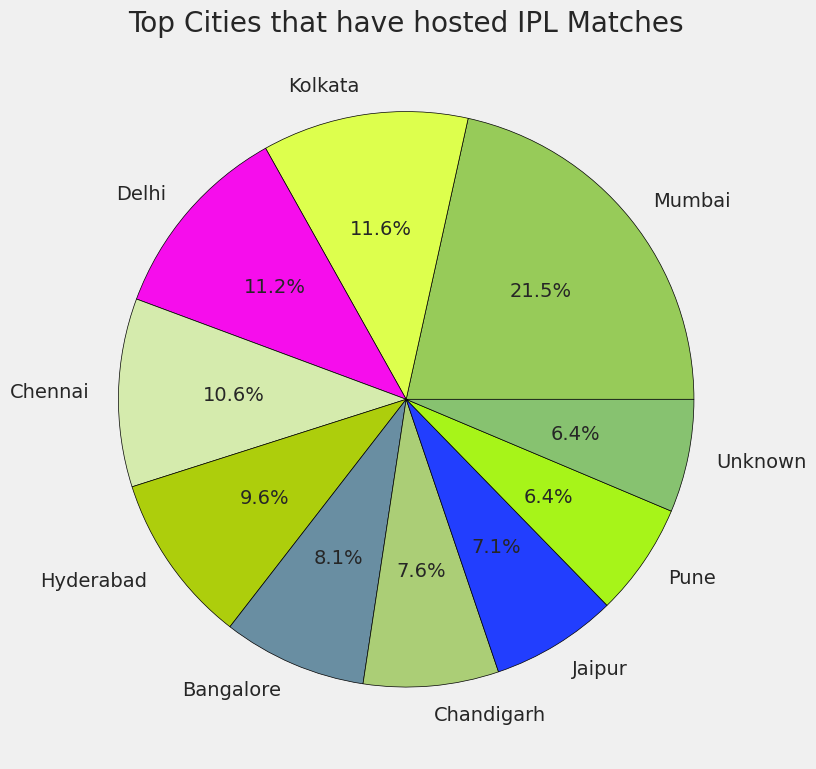

In [ ]:
top_cities = matches['city'].value_counts().reset_index(name='Match Count')[:10]

plt.figure(figsize=(8,8))
plt.pie(top_cities['Match Count'], labels = top_cities['city'],colors=random_colors(10),
       autopct='%1.1f%%', wedgeprops=dict(edgecolor='black'))
plt.title('Top Cities that have hosted IPL Matches')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3323/363838552.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dismissal_kind',data=deliveries,palette=random_colors(len(deliveries['dismissal_kind'].value_counts())))


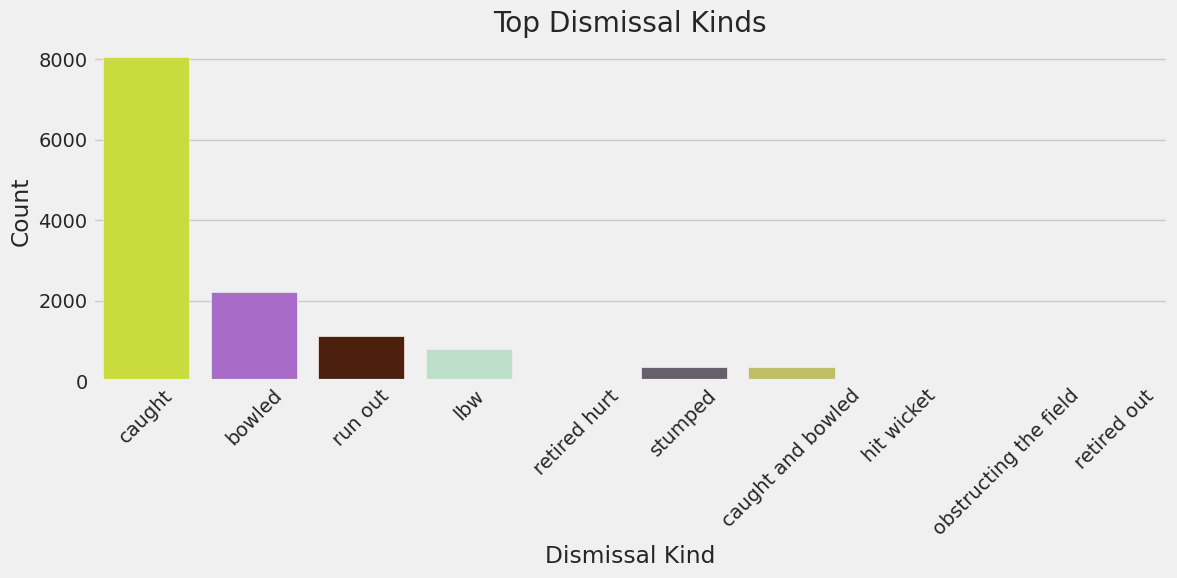

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='dismissal_kind',data=deliveries,palette=random_colors(len(deliveries['dismissal_kind'].value_counts())))
plt.title('Top Dismissal Kinds')
plt.xlabel('Dismissal Kind')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Top 10 Best Fielders in IPL**

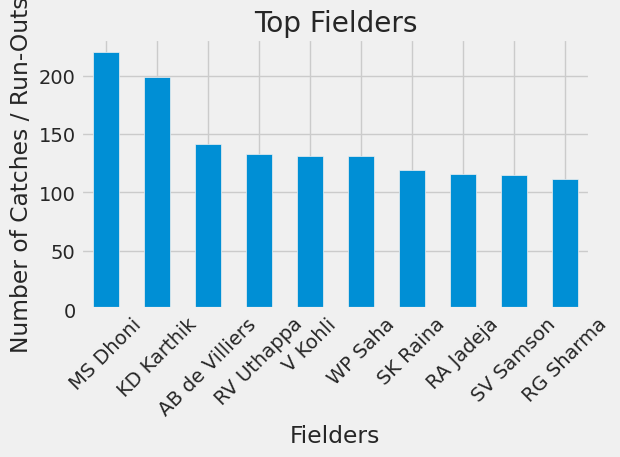

In [ ]:
deliveries['fielder'].value_counts()[:10].plot(kind='bar')
plt.title('Top Fielders')
plt.xlabel('Fielders')
plt.ylabel('Number of Catches / Run-Outs')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Analysis Over by Over**

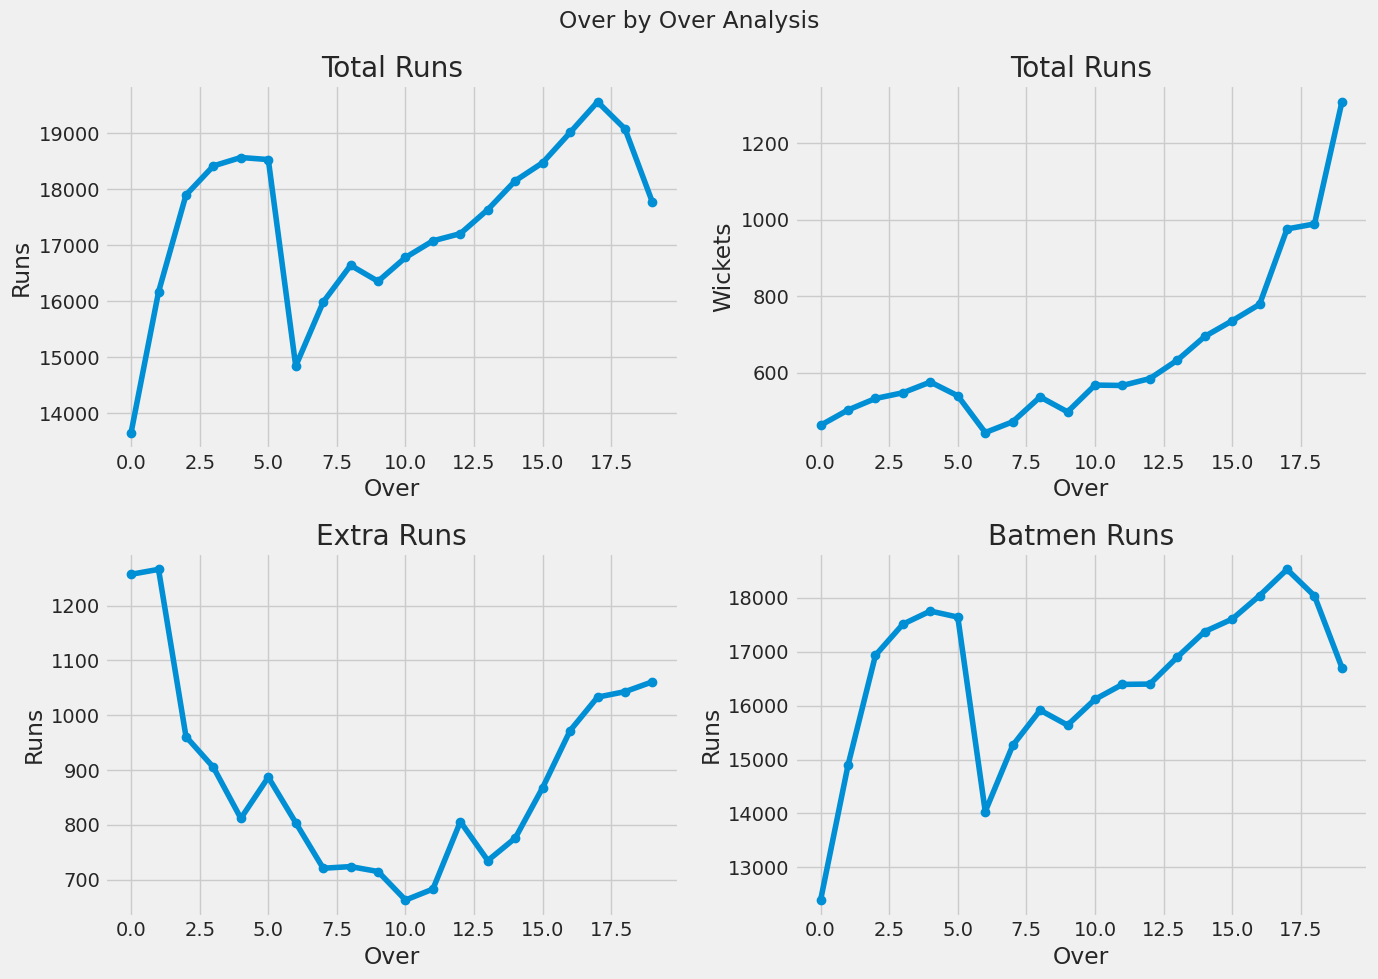

In [ ]:
over_summary = deliveries.groupby('over')[['total_runs','is_wicket','extra_runs','batsman_runs']].sum()

fig, axes = plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Over by Over Analysis')


axes[0,0].plot(over_summary.index,over_summary['total_runs'],marker='o')
axes[0,0].set_title('Total Runs')
axes[0,0].set_xlabel('Over')
axes[0,0].set_ylabel('Runs')

axes[0,1].plot(over_summary.index,over_summary['is_wicket'],marker='o')
axes[0,1].set_title('Total Runs')
axes[0,1].set_xlabel('Over')
axes[0,1].set_ylabel('Wickets')

axes[1,0].plot(over_summary.index,over_summary['extra_runs'],marker='o')
axes[1,0].set_title('Extra Runs')
axes[1,0].set_xlabel('Over')
axes[1,0].set_ylabel('Runs')

axes[1,1].plot(over_summary.index,over_summary['batsman_runs'],marker='o')
axes[1,1].set_title('Batmen Runs')
axes[1,1].set_xlabel('Over')
axes[1,1].set_ylabel('Runs')

plt.tight_layout()
plt.show()

**Toss Decision**

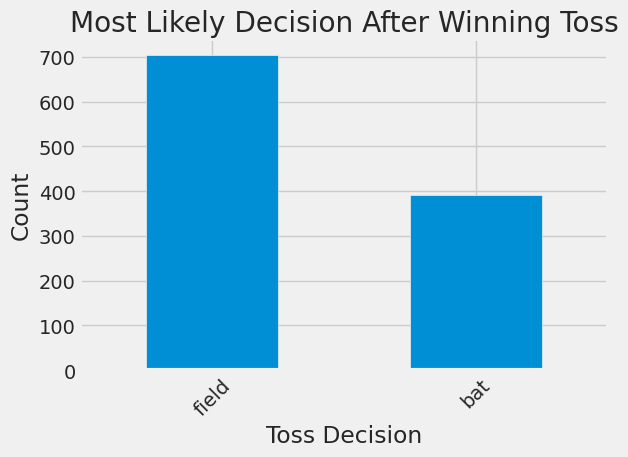

In [ ]:
matches['toss_decision'].value_counts().plot(kind='bar')
plt.title('Most Likely Decision After Winning Toss')
plt.xlabel('Toss Decision')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()